In [25]:
from hybrid_automaton import Automaton
from hybrid_automaton_runner import AutomatonRunner
import numpy as np
from hybrid_automaton_evaluation.figure_generator import continuous_states_over_time_fig, auxiliary_states_over_time_fig, automaton_states_over_time, transitions_times_over_time_fig
from colav_automaton import ColavAutomaton
import matplotlib.pyplot as plt

In [26]:
ha: Automaton = ColavAutomaton(heading_tolerance=0.2, k_theta=1.0, constant_velocity=2.0, acceptance_radius=20)
print (ha)

Hybrid Automaton Definition:
	name: COLAV Automaton
	id: 4
	initial_mode: Cruise
	modes: [Cruise, Transition_to_LOS, Fallback, Waypoint_Reached]
	transitions:
		Cruise --[e1]--> Transition_to_LOS
		Cruise --[e2]--> Transition_to_LOS
		Cruise --[e3]--> Fallback
		Cruise --[e4]--> Waypoint_Reached
		Transition_to_LOS --[e5]--> Cruise
		Transition_to_LOS --[e6]--> Cruise
		Waypoint_Reached --[e7]--> Cruise
	guards:
		e1: [heading_not_within_tolerance_guard]
		e2: [los_clear_to_waypoint_guard]
		e3: [unsafe_conditions_guard]
		e4: [waypoint_reached_guard]
		e5: [heading_within_tolerance_guard]
		e6: [unsafe_conditions_guard]
		e7: [virtual_waypoints_guard]
	resets:
		e1: <none>
		e2: generate_new_virtual_waypoint
		e3: <none>
		e4: <none>
		e5: <none>
		e6: <none>
		e7: pop_waypoint
	invariants:
		Cruise: [virtual_waypoints_guard]
		Transition_to_LOS: [virtual_waypoints_guard]
		Fallback: [virtual_waypoints_guard]
		Waypoint_Reached: [virtual_waypoints_guard]
	continous_dynamics:
		Cruise 

In [27]:
print (repr(ha))

stateDiagram-v2
    direction LR
    [*] --> Cruise
    Cruise --> Transition_to_LOS: e1
    Cruise --> Transition_to_LOS: e2
    Cruise --> Fallback: e3
    Cruise --> Waypoint_Reached: e4
    Transition_to_LOS --> Cruise: e5
    Transition_to_LOS --> Cruise: e6
    Waypoint_Reached --> Cruise: e7
    note right of Waypoint_Reached: invariant = is_goal_waypoint_invariant


In [28]:
x0 = np.array([0.0, 0.0, 0.0, 0.0, 0.0], dtype=float)
aux_t0 = {
    "waypoints": [np.array([20.0, 70.0]), np.array([20, -30])],
}

In [29]:
ha_runner: AutomatonRunner = AutomatonRunner(ha, sampling_rate=0.001)
await ha_runner.run(
    x0=x0,
    aux_x0=aux_t0,
    duration=10.0,
    real_time_mode=False,
    integrate=True,
    dt=0.01,
    collect_control=False
)

activating automaton 'COLAV Automaton'...
automaton 'COLAV Automaton' evaluation loop worker starting.
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise
T2LOS
cruise


{'continuous_states': [[0.01, array([0.  , 0.  , 0.  , 0.02, 0.  ])],
  [0.02, array([0.0002    , 0.        , 0.01292497, 0.0398    , 0.        ])],
  [0.03,
   array([5.97966757e-04, 5.14399351e-06, 2.57207101e-02, 5.94020000e-02,
          0.00000000e+00])],
  [0.04,
   array([1.19179028e-03, 2.04209252e-05, 3.83885485e-02, 7.88079800e-02,
          0.00000000e+00])],
  [0.05,
   array([1.97928946e-03, 5.06667347e-05, 5.09297863e-02, 9.80199002e-02,
          0.00000000e+00])],
  [0.060000000000000005,
   array([2.95821750e-03, 1.00566482e-04, 6.33457146e-02, 1.17039701e-01,
          0.00000000e+00])],
  [0.07, array([0.00412627, 0.00017466, 0.07563761, 0.1358693 , 0.        ])],
  [0.08, array([0.00548108, 0.00027733, 0.08780674, 0.15451061, 0.        ])],
  [0.09, array([0.00702023, 0.00041282, 0.09985435, 0.17296551, 0.        ])],
  [0.09999999999999999,
   array([0.00874127, 0.00058525, 0.11178169, 0.19123585, 0.        ])],
  [0.10999999999999999,
   array([0.01064169, 0.00079

{'continuous_states': [[0.01, array([0.  , 0.  , 0.  , 0.02, 0.  ])], [0.02, array([0.0002    , 0.        , 0.01292497, 0.0398    , 0.        ])], [0.03, array([5.97966757e-04, 5.14399351e-06, 2.57207101e-02, 5.94020000e-02,
       0.00000000e+00])], [0.04, array([1.19179028e-03, 2.04209252e-05, 3.83885485e-02, 7.88079800e-02,
       0.00000000e+00])], [0.05, array([1.97928946e-03, 5.06667347e-05, 5.09297863e-02, 9.80199002e-02,
       0.00000000e+00])], [0.060000000000000005, array([2.95821750e-03, 1.00566482e-04, 6.33457146e-02, 1.17039701e-01,
       0.00000000e+00])], [0.07, array([0.00412627, 0.00017466, 0.07563761, 0.1358693 , 0.        ])], [0.08, array([0.00548108, 0.00027733, 0.08780674, 0.15451061, 0.        ])], [0.09, array([0.00702023, 0.00041282, 0.09985435, 0.17296551, 0.        ])], [0.09999999999999999, array([0.00874127, 0.00058525, 0.11178169, 0.19123585, 0.        ])], [0.10999999999999999, array([0.01064169, 0.00079857, 0.12358997, 0.20932349, 0.        ])], [0.119

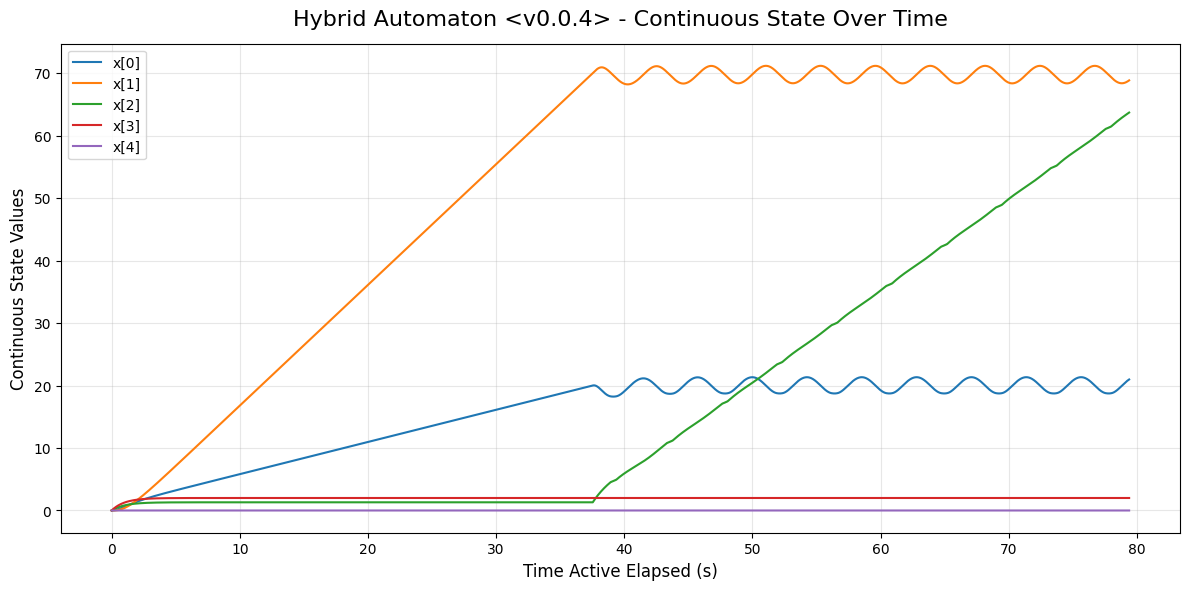

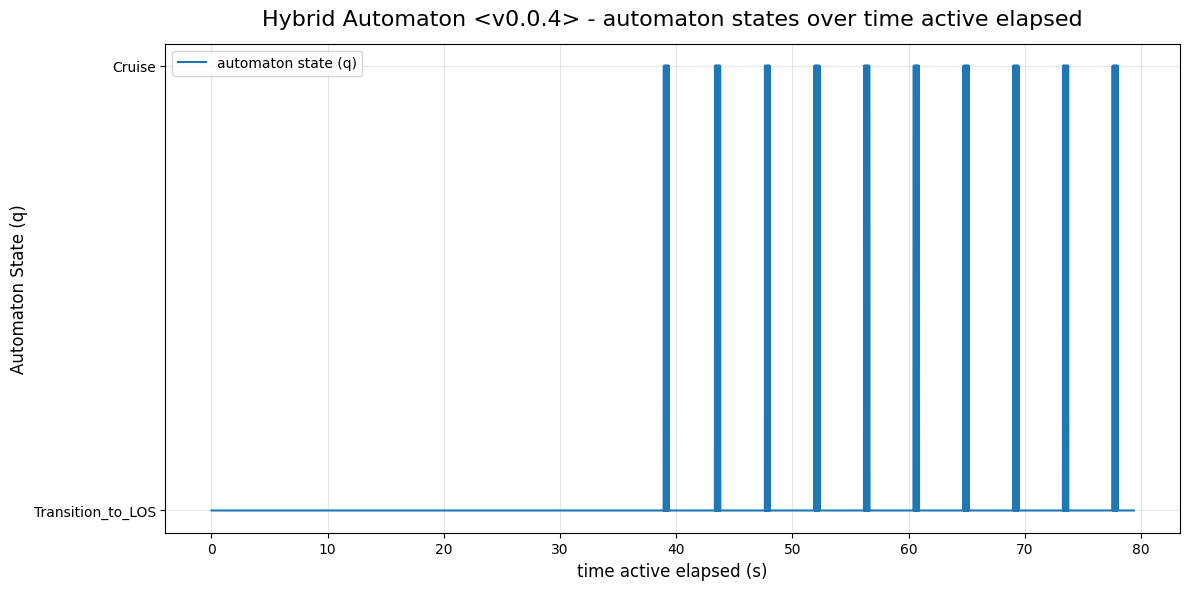

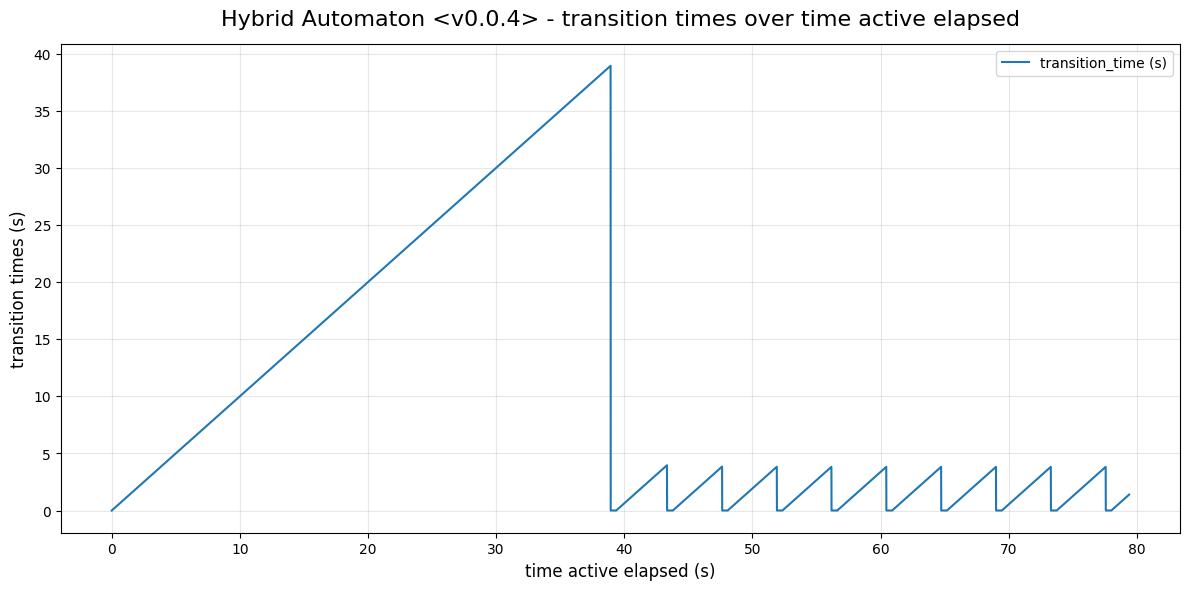

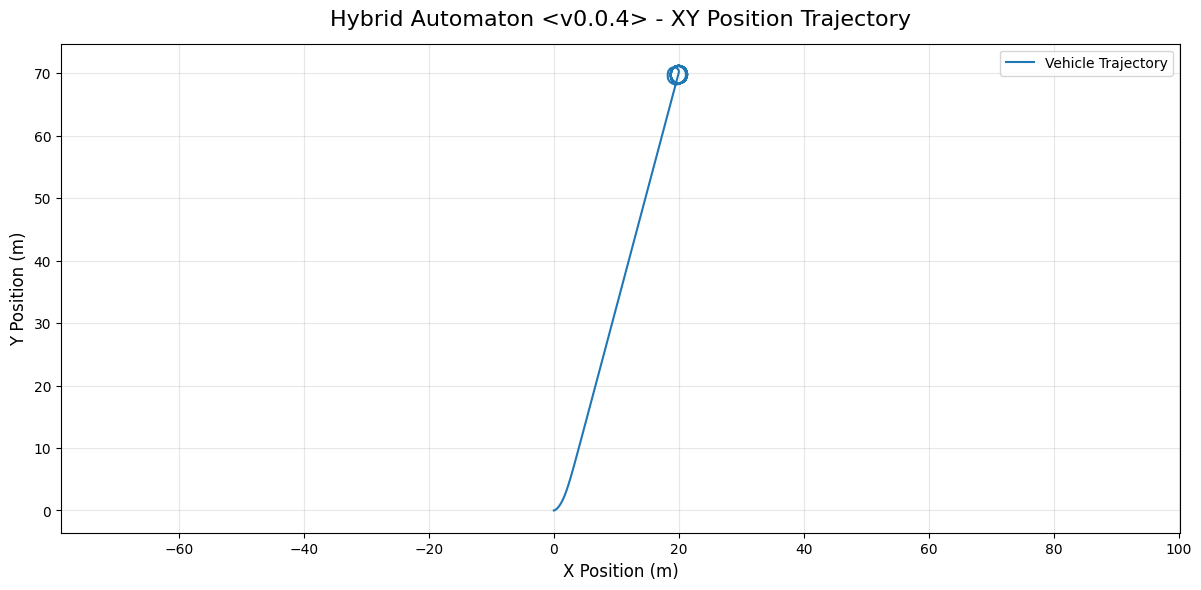

In [30]:
results = ha_runner.get_results()
print (results)
fig1 = continuous_states_over_time_fig(results['continuous_states'])
fig2 = auxiliary_states_over_time_fig(results['auxiliary_states'])
fig3 = automaton_states_over_time(results['automaton_states'])
fig4 = transitions_times_over_time_fig(results['transition_times'])

x = results['continuous_states']
def plot_xy_position_over_time():
    timestamps = [continuous_state[0] for continuous_state in x]
    continuous_state_values = np.array([continuous_state[1] for continuous_state in x])
    
    # Extract x and y positions (indices 0 and 1 of the state vector)
    x_positions = continuous_state_values[:, 0]
    y_positions = continuous_state_values[:, 1]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plot x vs y (trajectory in 2D space)
    ax.plot(x_positions, y_positions, label='Vehicle Trajectory')
    ax.set_title('Hybrid Automaton <v0.0.4> - XY Position Trajectory', fontsize=16, y=1.02)
    ax.set_xlabel("X Position (m)", fontsize=12)
    ax.set_ylabel("Y Position (m)", fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axis('equal')  # Equal aspect ratio for proper visualization
    
    fig.tight_layout()
    return fig

fig5 = plot_xy_position_over_time()

plt.show()